In [2]:
import numpy as np
import pandas as pd
from scipy import integrate
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
#import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from copy import deepcopy
import pickle
import os, sys
from importlib.machinery import SourceFileLoader
script_dir = os.path.abspath('')
# Define the relative path to the module
relative_module_path = "../rguimera-machine-scientist/parallel.py"
# Get the full absolute path
path = os.path.join(script_dir, relative_module_path)
ms = SourceFileLoader("ms", path).load_module()

try:
    from matplotlib import font_manager
    font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    prop = font_manager.FontProperties(fname='/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except Exception as e:
    print('Could not load Arial font')
    print(e)


def log_likelihood(theta):
    theta_params = theta[:-1]      # model parameters
    sigma = theta[-1]              # noise std
    
    if sigma <= 0:
        return -np.inf
    c = 0
    """
    par={}
    for p in bms_model.parameters:
        if p in parameters_in_use:
            par.update({p: theta[c]})
            c+=1
        else:
            par.update({p: 1.})
    bms_model.set_par_values(par)
    """
    x,y = data_int
    func_pred = bms_model.predict(x).to_numpy()
    
    # compute sum of squared residuals
    ssr = 0.0
    #for x, y in data_int:
    ssr = np.sum((y - func_pred)**2.)
    #print(np.sqrt(ssr)/len(data_int))
    """
    if not np.isfinite(ssr) or np.isnan(ssr):
        print('Nan in func',y,x,theta_params,func_pred)
    """
    n = len(data_int[0])
    return -n * np.log(sigma*np.sqrt(2*np.pi)) - ssr/(2*sigma**2)

def log_prior_theta(theta, eps=100.0):
    d = len(theta)
    return -0.5*np.sum(theta**2)/eps**2 - d*np.log(np.sqrt(2*np.pi)*eps)
def log_prior_sigma(sigma):
    if sigma <= 0:
        return -np.inf
    return -np.log(sigma)

def log_target(theta):
    return log_likelihood(theta) + log_prior_theta(theta[:-1]) + log_prior_sigma(theta[-1])

def log_posterior(theta):
    theta_params = theta[:-1]
    sigma = theta[-1]
    return log_likelihood(theta) + log_prior_theta(theta_params) + log_prior_sigma(sigma)


def chib_jeliazkov(samples, log_likelihood, log_prior_theta, log_prior_sigma, theta_star=None):
    """
    Estimate log marginal likelihood using Chib & Jeliazkov (2001)
    samples: MCMC samples, shape (n_samples, n_params+1)
    theta_star: optional point to evaluate posterior (default: posterior mean)
    """
    if theta_star is None:
        theta_star = np.mean(samples, axis=0)
        print(theta_star)
    
    # numerator: log p(y|theta*) + log p(theta*)
    log_num = log_likelihood(theta_star) + log_prior_theta(theta_star[:-1]) + log_prior_sigma(theta_star[-1])
    
    # posterior density at theta_star: estimate with kernel density over MCMC
    # We'll use a multivariate normal approximation to the posterior
    cov = np.cov(samples.T)
    log_posterior_est = multivariate_normal.logpdf(theta_star, mean=np.mean(samples, axis=0), cov=cov)
    
    log_marginal = log_num - log_posterior_est
    return log_marginal

def metropolis_hastings(log_posterior, theta_init, n_samples, proposal_cov=None, burn_in=0, thinning=1):
    """
    General Metropolis-Hastings MCMC sampler.
    
    Parameters:
    -----------
    log_posterior : function(theta) -> float
        Log posterior function: log(p(y|theta) * p(theta))
    theta_init : np.array
        Initial parameter vector
    n_samples : int
        Number of MCMC samples to return (after burn-in and thinning)
    proposal_cov : np.array (d x d)
        Covariance matrix for multivariate normal proposal. If None, defaults to identity.
    burn_in : int
        Number of initial samples to discard
    thinning : int
        Keep 1 out of every 'thinning' samples
    
    Returns:
    --------
    samples : np.array of shape (n_samples, len(theta_init))
        MCMC samples
    acceptance_rate : float
        Fraction of proposals accepted
    """
    theta_current = np.array(theta_init)
    d = len(theta_current)
    if proposal_cov is None:
        proposal_cov = np.eye(d) * 0.01  # small default step size
    
    samples = []
    n_accept = 0
    total_iter = 0
    n_total = burn_in + n_samples * thinning
    
    for i in range(n_total):
        # Propose new theta
        theta_proposal = np.random.multivariate_normal(theta_current, proposal_cov)
        
        # Compute log posterior
        log_post_current = log_posterior(theta_current)
        log_post_proposal = log_posterior(theta_proposal)
        
        # Acceptance probability
        log_alpha = log_post_proposal - log_post_current
        
        if np.log(np.random.rand()) < log_alpha:
            theta_current = theta_proposal
            n_accept += 1
        
        total_iter += 1
        
        # Store samples after burn-in and apply thinning
        if i >= burn_in and ((i - burn_in) % thinning == 0):
            samples.append(theta_current.copy())
    
    samples = np.array(samples)
    acceptance_rate = n_accept / total_iter
    return samples, acceptance_rate


def hessian_numeric(log_target, theta0, h=1e-4):
    """
    Numerically compute the Hessian of log_target at theta0
    using central finite differences.

    Parameters
    ----------
    log_target : callable
        log_target(theta) -> scalar
        Must accept theta as shape (k,) and return a scalar.
    theta0 : array-like, shape (k,)
        Point at which to evaluate the Hessian.
    h : float
        Finite difference step size.

    Returns
    -------
    H : ndarray, shape (k, k)
        Hessian matrix evaluated at theta0.
    """
    theta0 = np.asarray(theta0, dtype=float)
    k = theta0.size
    H = np.zeros((k, k), dtype=float)

    f0 = log_target(theta0)

    # Unit vectors
    E = np.eye(k)

    for i in range(k):
        for j in range(i, k):
            ei = E[i] * h
            ej = E[j] * h

            if i == j:
                f_pp = log_target(theta0 + ei)
                f_mm = log_target(theta0 - ei)
                H[i, i] = (f_pp - 2*f0 + f_mm) / h**2
            else:
                f_pp = log_target(theta0 + ei + ej)
                f_pm = log_target(theta0 + ei - ej)
                f_mp = log_target(theta0 - ei + ej)
                f_mm = log_target(theta0 - ei - ej)

                H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4*h**2)
                H[j, i] = H[i, j]  # symmetry

    return H
def compute_logZ_BIC(theta_hat):
    """
    Compute BIC and the corresponding log marginal likelihood approximation.

    Parameters
    ----------
    log_likelihood : float
        Log-likelihood at the maximum (MLE / MAP if using flat prior)
    n_data : int
        Number of data points
    n_params : int
        Number of free parameters

    Returns
    -------
    bic : float
        BIC value
    logZ_bic : float
        Log marginal likelihood approximation from BIC
    """
    x,y = data_int
    func_pred = bms_model.predict(x).to_numpy()
    
    # compute sum of squared residuals
    ssr = 0.0
    #for x, y in data_int:
    ssr = np.sum((y - func_pred)**2.)
    
    n = len(data_int[0])
    k=len(theta_hat)
    bic = n * (np.log(2.0 * np.pi) + np.log(ssr/n) + 1) + (k) * np.log(n)
    logZ_bic = -0.5 * bic
    return logZ_bic

-c1*c2*x*(c3**3+x)+c1+x**6
c1*c2*(c3+(c2-x**2)*(c4**(c1+c5+x))**(c5*x))
-c1*c2*x*(c3*c2+x)+c1+x**6
c1*x*(c2+x)/c3+c3+x**6
c1+x**6-x*(c2+x)*(c1+c3)/c1
['-c1*c2*x*(c3**3+x)+c1+x**6', 'c1*c2*(c3+(c2-x**2)*(c4**(c1+c5+x))**(c5*x))', '-c1*c2*x*(c3*c2+x)+c1+x**6', 'c1*x*(c2+x)/c3+c3+x**6', 'c1+x**6-x*(c2+x)*(c1+c3)/c1']
100
BMS bic -165.691298143950
BMS bic -7.37345009527477
BMS pars [-1.49958609 -2.00261722 -0.54416509]


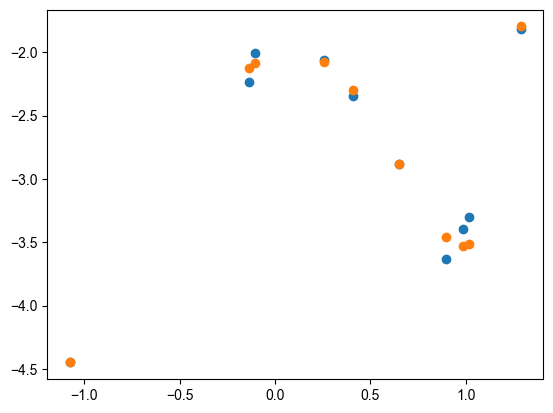

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 6.008424645952085
        x: [ 1.007e-01]
      nit: 5
      jac: [-5.960e-08]
 hess_inv: [[ 4.609e-04]]
     nfev: 25
     njev: 11
MAP pars [-1.49958609 -2.00261722 -0.54416509  0.10068251]
8.268446058200908
-16.57265392506851
2.295783220915518
-6.008424645952085
BMS BIC -7.37345009527477 BIC -7.373450095274775
Chib-Jeliazkov 8.104867199026405 log Z (BIC) 3.6867250476373874
BMS bic -163.721473217393
BMS bic -4.83390068235327
BMS pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424]


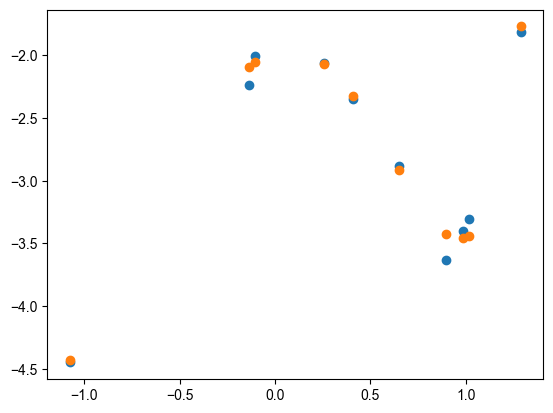

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 15.921932581270555
        x: [ 9.080e-02]
      nit: 5
      jac: [ 0.000e+00]
 hess_inv: [[ 3.749e-04]]
     nfev: 28
     njev: 11
MAP pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424  0.09080288]
9.30125643716416
-27.62225328557359
2.399064267138874
-15.921932581270555
BMS BIC -4.83390068235327 BIC -4.8339006823532635
Chib-Jeliazkov 9.078964885974562 log Z (BIC) 2.4169503411766318
BMS bic -165.691298143949
BMS bic -7.37345013817741
BMS pars [-1.49958609 -2.00261722  0.10745352]


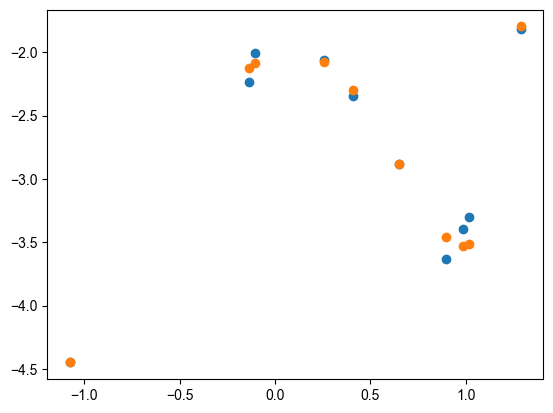

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 6.0084103938862325
        x: [ 1.007e-01]
      nit: 5
      jac: [-5.960e-08]
 hess_inv: [[ 4.609e-04]]
     nfev: 25
     njev: 11
MAP pars [-1.49958609 -2.00261722  0.10745352  0.10068251]
8.268446079900603
-16.572639696599104
2.295783222812269
-6.0084103938862325
BMS BIC -7.37345013817741 BIC -7.373450138177402
Chib-Jeliazkov 8.065816821312687 log Z (BIC) 3.686725069088701
BMS bic -165.691298143949
BMS bic -7.37345006391653
BMS pars [-0.1611358  -2.00261722  6.0140536 ]


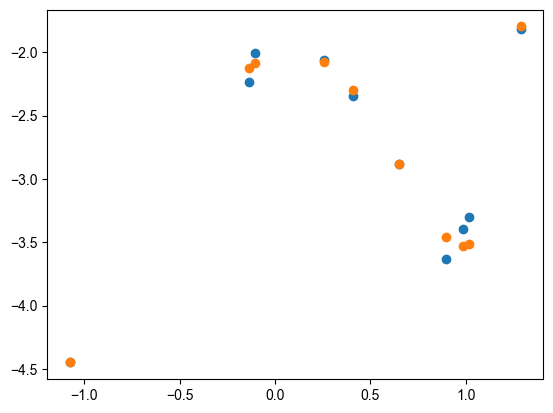

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 6.0101071597664575
        x: [ 1.007e-01]
      nit: 5
      jac: [ 4.172e-07]
 hess_inv: [[ 4.609e-04]]
     nfev: 25
     njev: 11
MAP pars [-0.1611358  -2.00261722  6.0140536   0.10068251]
8.268446044679148
-16.574336421635852
2.295783217190246
-6.0101071597664575
BMS BIC -7.37345006391653 BIC -7.373450063916534
Chib-Jeliazkov 7.952508290327412 log Z (BIC) 3.686725031958267
BMS bic -165.691298143949
BMS bic -7.37345011927170
BMS pars [-0.1611358  -4.01143638 -2.00261722]


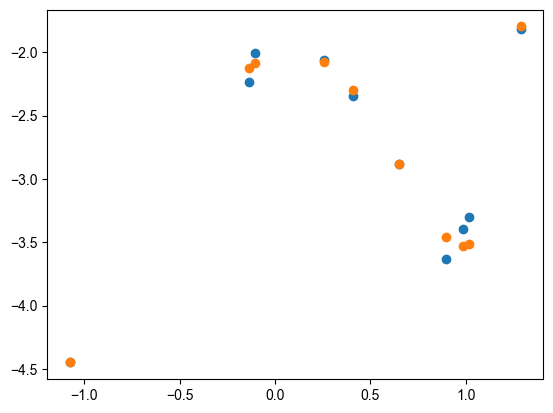

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 6.00910326837902
        x: [ 1.007e-01]
      nit: 5
      jac: [ 1.788e-07]
 hess_inv: [[ 4.609e-04]]
     nfev: 25
     njev: 11
MAP pars [-0.1611358  -4.01143638 -2.00261722  0.10068251]
8.268446070856864
-16.573332560693757
2.2957832214578726
-6.00910326837902
BMS BIC -7.37345011927170 BIC -7.373450119271707
Chib-Jeliazkov 7.95420492292962 log Z (BIC) 3.6867250596358536
100
BMS bic -165.691298143950
BMS bic -41.5612742884864
BMS pars [-1.49958609 -2.00261722 -0.54416509]


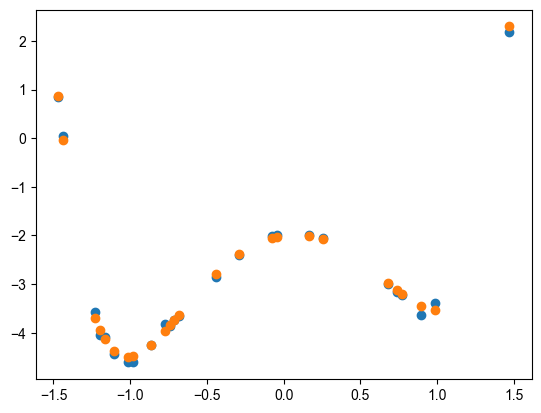

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -13.163278224867618
        x: [ 7.988e-02]
      nit: 4
      jac: [ 5.245e-05]
 hess_inv: [[ 1.227e-04]]
     nfev: 103
     njev: 44
MAP pars [-1.49958609 -2.00261722 -0.54416509  0.07987563]
27.208647695250136
-16.57265392506851
2.527284454685993
13.163278224867618
BMS BIC -41.5612742884864 BIC -41.56127428848644
Chib-Jeliazkov 26.3084475763075 log Z (BIC) 20.78063714424322
BMS bic -163.721473217393
BMS bic -34.7622682250674
BMS pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424]


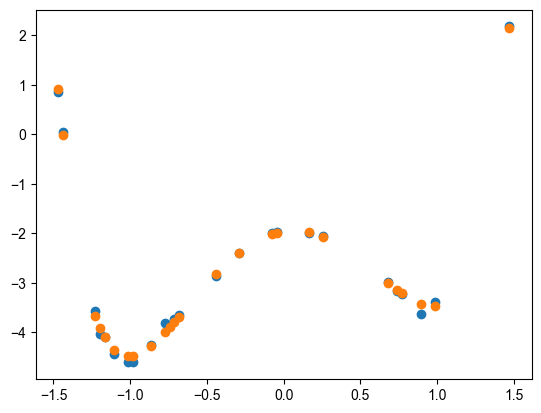

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.9258265692473677
        x: [ 8.045e-02]
      nit: 5
      jac: [ 8.941e-07]
 hess_inv: [[ 1.244e-04]]
     nfev: 28
     njev: 11
MAP pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424  0.08045482]
27.028020411014538
-27.62225328557359
2.5200594438064186
1.9258265692473677
BMS BIC -34.7622682250674 BIC -34.762268225067416
Chib-Jeliazkov 26.072596339606093 log Z (BIC) 17.381134112533708
BMS bic -165.691298143949
BMS bic -41.5612742129799
BMS pars [-1.49958609 -2.00261722  0.10745352]


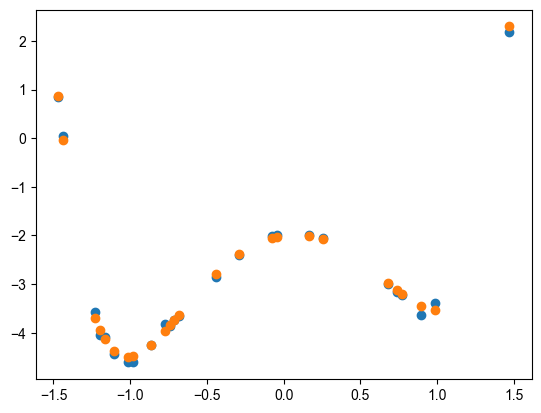

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -13.163292414073634
        x: [ 7.988e-02]
      nit: 4
      jac: [ 5.198e-05]
 hess_inv: [[ 1.227e-04]]
     nfev: 109
     njev: 47
MAP pars [-1.49958609 -2.00261722  0.10745352  0.07987563]
27.20864765797441
-16.572639696599104
2.527284452698328
13.163292414073634
BMS BIC -41.5612742129799 BIC -41.561274212979924
Chib-Jeliazkov 26.284519052073207 log Z (BIC) 20.780637106489962
BMS bic -165.691298143949
BMS bic -41.5612743538794
BMS pars [-0.1611358  -2.00261722  6.0140536 ]


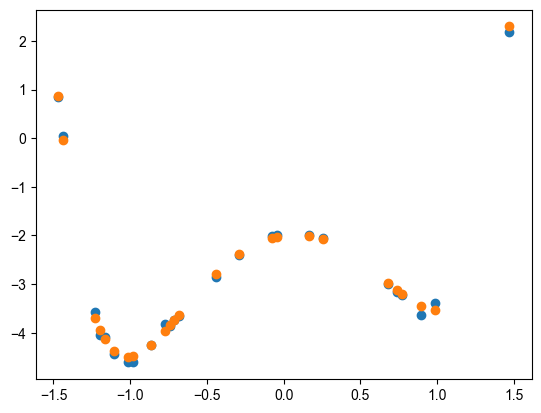

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -13.161595762304637
        x: [ 7.988e-02]
      nit: 4
      jac: [ 5.245e-05]
 hess_inv: [[ 1.227e-04]]
     nfev: 91
     njev: 38
MAP pars [-0.1611358  -2.00261722  6.0140536   0.07987563]
27.20864772858036
-16.574336421635852
2.52728445536013
13.161595762304637
BMS BIC -41.5612743538794 BIC -41.56127435387944
Chib-Jeliazkov 26.240607461304656 log Z (BIC) 20.78063717693972
BMS bic -165.691298143949
BMS bic -41.5612742450400
BMS pars [-0.1611358  -4.01143638 -2.00261722]


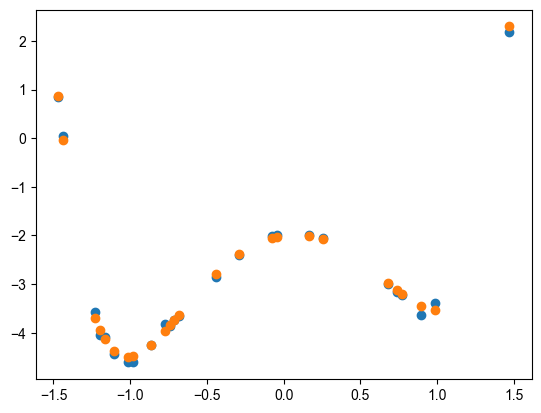

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -13.162599566650208
        x: [ 7.988e-02]
      nit: 5
      jac: [ 4.518e-05]
 hess_inv: [[ 1.356e-04]]
     nfev: 31
     njev: 13
MAP pars [-0.1611358  -4.01143638 -2.00261722  0.07987563]
27.20864766212395
-16.573332560693757
2.5272844652200126
13.162599566650208
BMS BIC -41.5612742450400 BIC -41.56127424503997
Chib-Jeliazkov 26.240392495911415 log Z (BIC) 20.780637122519984
100
BMS bic -165.691298143950
BMS bic -74.0245908243635
BMS pars [-1.49958609 -2.00261722 -0.54416509]


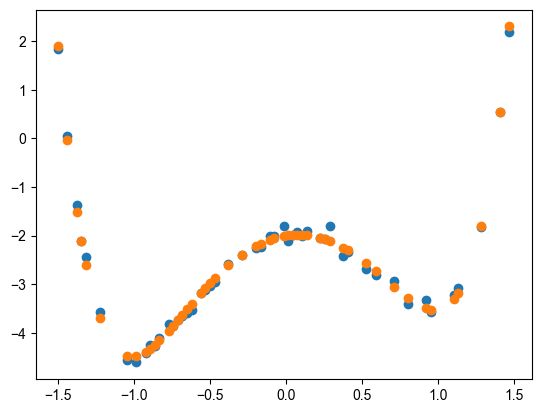

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -30.584319855687255
        x: [ 9.773e-02]
      nit: 6
      jac: [ 4.292e-06]
 hess_inv: [[ 9.371e-05]]
     nfev: 31
     njev: 12
MAP pars [-1.49958609 -2.00261722 -0.54416509  0.09772804]
44.83140703353433
-16.57265392506851
2.325566747221435
30.584319855687255
BMS BIC -74.0245908243635 BIC -74.02459082436343
Chib-Jeliazkov 43.539382491425286 log Z (BIC) 37.012295412181714
BMS bic -163.721473217393
BMS bic -70.0722852055512
BMS pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424]


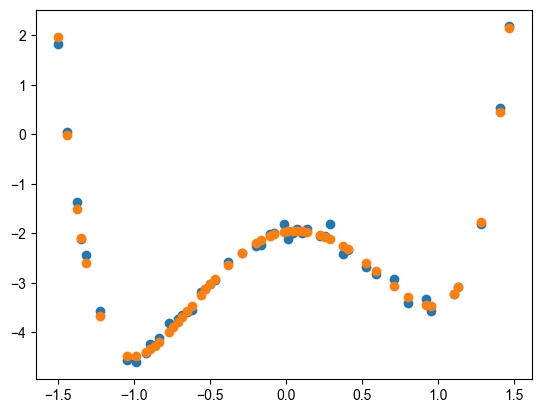

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -21.509308095124812
        x: [ 9.402e-02]
      nit: 4
      jac: [ 3.743e-05]
 hess_inv: [[ 8.667e-05]]
     nfev: 100
     njev: 42
MAP pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424  0.09401658]
46.767277256399204
-27.62225328557359
2.364284124299197
21.509308095124812
BMS BIC -70.0722852055512 BIC -70.07228520555121
Chib-Jeliazkov 45.415736970633674 log Z (BIC) 35.036142602775605
BMS bic -165.691298143949
BMS bic -74.0245908004280
BMS pars [-1.49958609 -2.00261722  0.10745352]


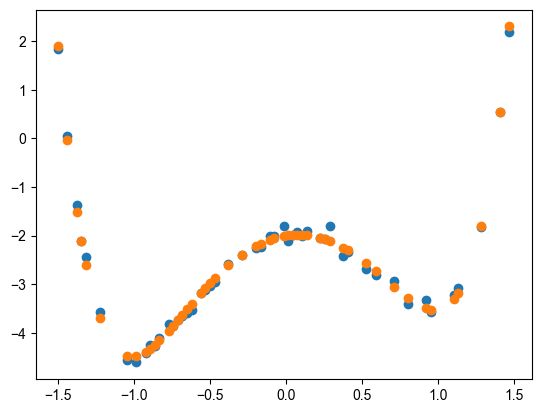

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -30.584334071949566
        x: [ 9.773e-02]
      nit: 6
      jac: [ 4.768e-06]
 hess_inv: [[ 9.371e-05]]
     nfev: 31
     njev: 12
MAP pars [-1.49958609 -2.00261722  0.10745352  0.09772804]
44.831407020921816
-16.572639696599104
2.3255667476268562
30.584334071949566
BMS BIC -74.0245908004280 BIC -74.02459080042794
Chib-Jeliazkov 43.55105149052293 log Z (BIC) 37.01229540021397
BMS bic -165.691298143949
BMS bic -74.0245908942923
BMS pars [-0.1611358  -2.00261722  6.0140536 ]


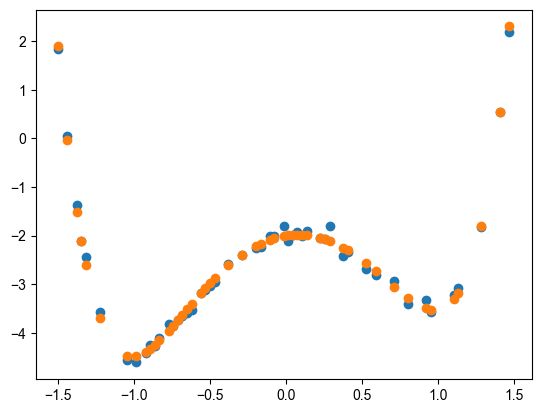

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -30.582637394783617
        x: [ 9.773e-02]
      nit: 6
      jac: [ 4.530e-06]
 hess_inv: [[ 9.371e-05]]
     nfev: 31
     njev: 12
MAP pars [-0.1611358  -2.00261722  6.0140536   0.09772804]
44.83140706773774
-16.574336421635852
2.3255667486817253
30.582637394783617
BMS BIC -74.0245908942923 BIC -74.02459089429225
Chib-Jeliazkov 43.48824138552347 log Z (BIC) 37.01229544714612
BMS bic -165.691298143949
BMS bic -74.0245908145877
BMS pars [-0.1611358  -4.01143638 -2.00261722]


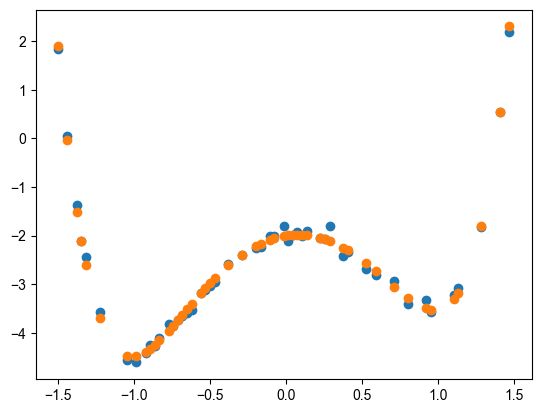

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -30.583641215076373
        x: [ 9.773e-02]
      nit: 6
      jac: [ 1.669e-06]
 hess_inv: [[ 9.371e-05]]
     nfev: 31
     njev: 12
MAP pars [-0.1611358  -4.01143638 -2.00261722  0.09772804]
44.83140702594227
-16.573332560693757
2.3255667498278596
30.583641215076373
BMS BIC -74.0245908145877 BIC -74.02459081458774
Chib-Jeliazkov 43.52628503414549 log Z (BIC) 37.01229540729387
100
BMS bic -165.691298143950
BMS bic -134.331088038978
BMS pars [-1.49958609 -2.00261722 -0.54416509]


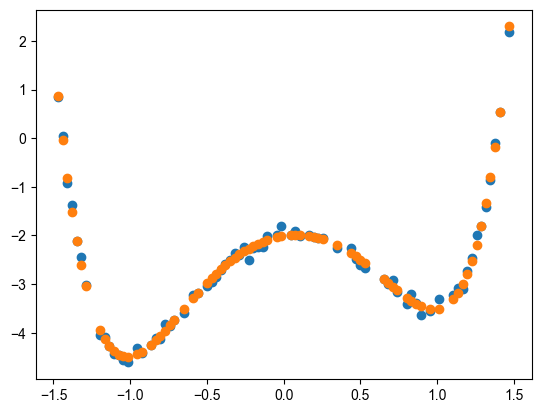

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -61.660797074485664
        x: [ 8.749e-02]
      nit: 5
      jac: [-1.431e-06]
 hess_inv: [[ 5.038e-05]]
     nfev: 28
     njev: 11
MAP pars [-1.49958609 -2.00261722 -0.54416509  0.08748964]
75.79721616382221
-16.57265392506851
2.436234835731956
61.660797074485664
BMS BIC -134.331088038978 BIC -134.3310880389783
Chib-Jeliazkov 74.31637957324614 log Z (BIC) 67.16554401948915
BMS bic -163.721473217393
BMS bic -124.397995876636
BMS pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424]


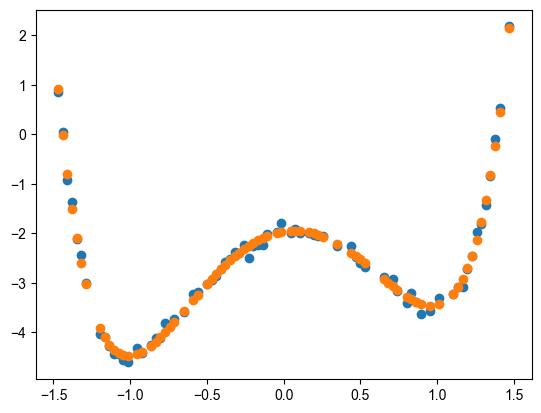

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -49.953485640110515
        x: [ 8.825e-02]
      nit: 5
      jac: [-4.768e-07]
 hess_inv: [[ 5.126e-05]]
     nfev: 28
     njev: 11
MAP pars [-3.04507598 -2.54465101  2.5042307   3.28032542  1.18926424  0.08825008]
75.14815819686609
-27.62225328557359
2.427580728818017
49.953485640110515
BMS BIC -124.397995876636 BIC -124.3979958766358
Chib-Jeliazkov 73.62281859139725 log Z (BIC) 62.1989979383179
BMS bic -165.691298143949
BMS bic -134.331088154372
BMS pars [-1.49958609 -2.00261722  0.10745352]


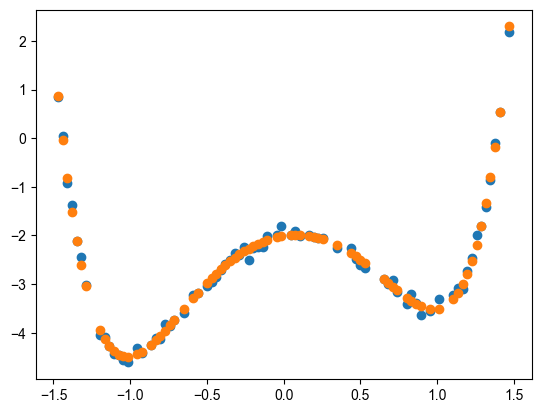

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -61.66081136142121
        x: [ 8.749e-02]
      nit: 5
      jac: [-9.537e-07]
 hess_inv: [[ 5.038e-05]]
     nfev: 28
     njev: 11
MAP pars [-1.49958609 -2.00261722  0.10745352  0.08748964]
75.79721622150967
-16.572639696599104
2.436234836510645
61.66081136142121


In [ ]:
# Load corpus of functions:

with open('1d_data_models.pkl','rb') as file:
    corpus_models = pickle.load(file)

models = []

for m in list(corpus_models.keys())[::-1]:
    if np.all(np.abs(np.array(list(corpus_models[m].par_values['d0'].values())))<15.):
        print(m)
        models.append(m)
    if len(models)==5:
        break
print(models)

records = []
results = {}
for n in [10,25,50,75,100]:
    x = corpus_models[models[0]].x['d0']
    print(len(x))
    y = corpus_models[models[0]].y['d0']

    x_vals = x['x'].to_numpy()
    y_vals = y.to_numpy()

    idx = np.random.choice(len(x_vals), size=n, replace=False)
    
    x_vals = x_vals[idx]
    y_vals = y_vals[idx]
    
    data_int = [pd.DataFrame(data={'x':x_vals}), pd.Series(y_vals)]


    for model in models:
        
        s=0.5
        bms_model = deepcopy(corpus_models[model])

        if bms_model.latex() not in list(results.keys()):
            results.update({bms_model.latex() : {} })
        
        
        print('BMS bic', bms_model.bic)
        bms_model.x['d0'] = pd.DataFrame(data={'x':x_vals})
        bms_model.y['d0'] = pd.Series(y_vals)
    
        bms_model.get_bic(reset=True,fit=True,verbose=True)
        print('BMS bic', bms_model.bic)
        parameters_in_use = set([p.value for p in bms_model.ets[0] if p.value in bms_model.parameters])
        theta_hat = np.array([bms_model.par_values['d0'][p] for p in parameters_in_use])#+[s])
        print('BMS pars',theta_hat)
        # Get MAE
        plt.scatter(x_vals,y_vals)
        plt.scatter(x_vals,bms_model.predict(pd.DataFrame(data={'x':x_vals})).to_numpy())
        plt.show()
        def neg_log_post(theta):
            #print(theta)
            return -log_posterior(theta)
        
        res = minimize(lambda x: neg_log_post(np.concatenate((theta_hat, x))), np.array(s) , method="BFGS")
        print(res)
        theta_hat = np.concatenate((theta_hat, res.x))
        print('MAP pars',theta_hat)
        print(log_likelihood(theta_hat))
        print(log_prior_theta(theta_hat[:-1]))
        print(log_prior_sigma(theta_hat[-1]))
        print(log_posterior(theta_hat))
        H = -hessian_numeric(log_posterior, theta_hat)
        cov_post = np.linalg.inv(H)
        
        d = len(theta_hat)
        proposal_cov = (2.4**2 / d) * cov_post
        samples, acc_rate = metropolis_hastings(
                    log_posterior=log_posterior,
                    theta_init=theta_hat,
                    n_samples=50000,
                    proposal_cov=proposal_cov,
                    burn_in=1000,
                    thinning=2
                )
        burnin = 10_000
        posterior_sample = samples[burnin:]
        sample_S = posterior_sample[:10_000]
        logZ = chib_jeliazkov(sample_S, log_likelihood, log_prior_theta, log_prior_sigma,theta_star=theta_hat)
        logZ_BIC = compute_logZ_BIC(theta_hat)
        print('BMS BIC',bms_model.bic, 'BIC',-2.*compute_logZ_BIC(theta_hat))
        print('Chib-Jeliazkov',logZ, 'log Z (BIC)', logZ_BIC)
        results[bms_model.latex()].update({n : (logZ - logZ_BIC)/logZ })

        # Prior contribution
        prior = bms_model.EP

        # Likelihood contributions
        ll_exact = -logZ
        ll_bic = -logZ_BIC

        # Description lengths
        DL_exact = -logZ + prior
        DL_BIC   = -logZ_BIC + prior

        records.append({
            "model": bms_model.latex(),
            "n_points": n,
            "logZ_exact": logZ,
            "logZ_BIC": logZ_BIC,
            "likelihood_exact": ll_exact,
            "likelihood_BIC": ll_bic,
            "prior": prior,
            "DL_exact": DL_exact,
            "DL_BIC": DL_BIC,
        })

# Save everything
df = pd.DataFrame(records)
df.to_csv("description_length_results.csv", index=False)


plt.scatter(x_vals,y_vals)
plt.xlabel('x')
plt.xlabel('y')
plt.savefig('model_relative_BIC.pdf',dpi=300)

In [ ]:
models = list(results.keys())
Ns = sorted(next(iter(results.values())).keys())

fig, ax = plt.subplots(figsize=(10, 6))

x_base = np.arange(len(models))
bar_width = 0.12

# offsets control the diagonal effect
x_offset_step = 0.12
y_offset_step = 0.00

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(Ns)))

for i, N in enumerate(Ns):
    x = x_base + i * x_offset_step
    heights = [results[m][N] for m in models]
    y_base = i * y_offset_step

    ax.bar(
        x,
        heights,
        width=bar_width,
        bottom=y_base,
        color=colors[i],
        label=f"N = {N}",
        alpha=0.9
    )

# formatting
ax.set_xticks(x_base + x_offset_step * (len(Ns)-1)/2)
ax.set_xticklabels([f'${model}$' for model in models], rotation=60)
ax.set_ylabel(r"Relative difference log-likelihood")
#ax.set_title("Difference between log-likelihood and -BIC/2")
ax.legend(title="Data size", frameon=False)

plt.tight_layout()
plt.savefig('relative_diff_models.pdf',dpi=300)
plt.show()

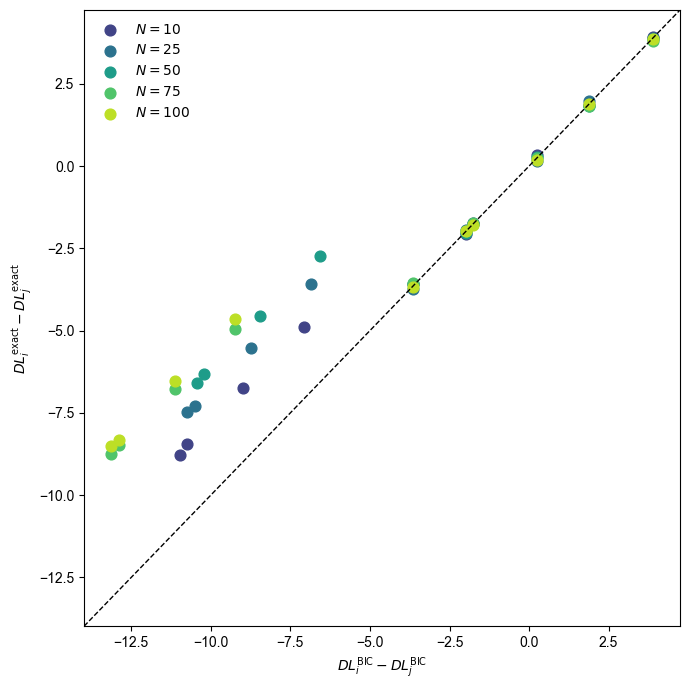

In [11]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("description_length_results.csv")

Ns = sorted(df["n_points"].unique())
models = sorted(df["model"].unique())

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(Ns)))

fig, ax = plt.subplots(figsize=(7,7))

for c, N in zip(colors, Ns):

    dfn = df[df["n_points"] == N]

    x = []
    y = []

    for m1, m2 in itertools.combinations(models, 2):

        row1 = dfn[dfn.model == m1].iloc[0]
        row2 = dfn[dfn.model == m2].iloc[0]

        x.append(row1["DL_BIC"] - row2["DL_BIC"])
        y.append(row1["DL_exact"] - row2["DL_exact"])

    ax.scatter(x, y, s=60, color=c, label=f"$N={N}$")

# y=x reference line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(r"$DL_i^{\mathrm{BIC}}-DL_j^{\mathrm{BIC}}$")
ax.set_ylabel(r"$DL_i^{\mathrm{exact}}-DL_j^{\mathrm{exact}}$")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("DL_pairwise_scatter.pdf", dpi=300)
plt.show()